# Demos: Lecture 5

In [1]:
import pennylane as qml
from pennylane import numpy as np

## Exercise 1: $Y$-basis measurement

Implement the circuit below, but perform a measurement in the $Y$ basis, 
 
$$
 \ket{p} = \frac{1}{\sqrt{2}} \ket{0} + \frac{i}{\sqrt{2}}\ket{1}, \quad 
 \ket{m} = \frac{1}{\sqrt{2}} \ket{0} - \frac{i}{\sqrt{2}}\ket{1}.
$$

Plot the outcome probability of $|p\rangle$, as a function of $\theta$. How does $\theta$ affect the measurement outcome probabilities?
 
<img src="fig/exercise-circuit.png" width=300>

In [4]:
dev = qml.device('default.qubit', wires=1)
  
def convert_to_y_basis():
    # YOUR CODE HERE; find a circuit that sends 
    # |0> -> |p> and |1> -> |m>
    qml.Hadamard(0)
    qml.S(0)
    
@qml.qnode(dev)
def circuit_with_y_basis_measurement(theta):  
    # Step 1: run the circuit above
    qml.Hadamard(0)
    qml.RZ(theta, 0)
    # Step 2: measure in the y-basis and return the probabilities
    #qml.adjoint(convert_to_y_basis)()

    convert_from_y_basis = qml.adjoint(convert_to_y_basis)
    convert_from_y_basis()
    
    return qml.probs()

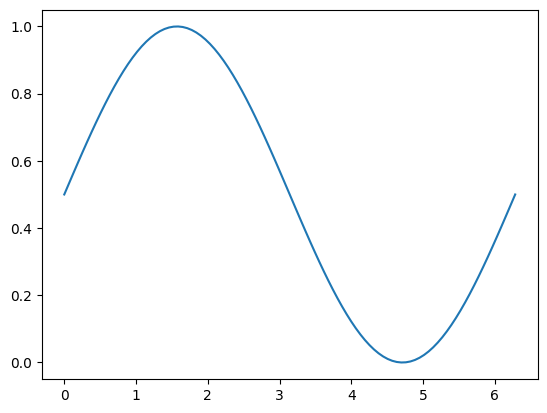

In [5]:
import matplotlib.pyplot as plt

thetas = np.linspace(0, 2*np.pi, 100)
plt.plot(thetas, [circuit_with_y_basis_measurement(t)[0] for t in thetas])

In [15]:
dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def func():
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.SWAP(wires=[0, 2])
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 0])
    return qml.state()

In [7]:
func()

array([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j, 0.        +0.j])

In [9]:
draw_func = qml.draw(func)
print(draw_func())

0: ──H─╭SWAP─┤  State
1: ────╰SWAP─┤  State


(<Figure size 700x400 with 1 Axes>, <Axes: >)

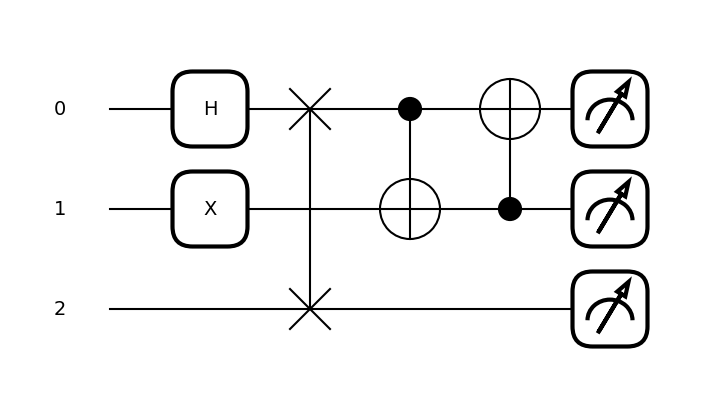

In [16]:
qml.draw_mpl(func)()

## Exercise 2: One-bit adder

Use a combination of $X$, CNOT, and TOF to create a quantum version of a one-bit adder. Test it in PennyLane on all possible bit values of $a$ and $b$.
 
<img src="fig/half-adder-blank.png" width=300>

In [ ]:
dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def one_bit_adder(a, b):
    # Step 1: initialize a and b based on input values

    # Step 2: perform the addition to create sum and carry bits

    # Step 3: return a meaningful measurement result
    return

## Exercise 3: Controlled addition

Using your adder from earlier, implement a circuit in PennyLane that uses `qml.ctrl` to perform addition if the control qubit is in state $|0\rangle$, and flip the state of the control qubit if the carry bit is 1.

<img src="fig/controlled_add.png" width=300>